# Régression du prix — pipeline complet (french-second-hand-cars)

Notebook **end-to-end** : nettoyage → features (dont marque premium) → comparaison de modèles **linéaires régularisés** avec hyperparamètres.

**Fil conducteur :**
1. Baseline linéaire nue (6 features numériques) — point de repère.
2. Enrichissement : palier premium (marque) + boîte auto + garantie constructeur + durée garantie.
3. Panel **LinearRegression / Ridge / Lasso / ElasticNet** avec `StandardScaler` + `GridSearchCV` (validation croisée).

> On reste volontairement sur du **linéaire** (interprétable, aligné BC04) avant tout modèle « boîte noire ».
> Code partagé dans `ml/src/features.py` ; données brutes jamais modifiées.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "../../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from features import clean_cars, load_premium_table, add_brand_features

RAW = "../../data/french-second-hand-cars/raw/French_second_hand_cars.csv"
REF = "../../references/premium_brand.csv"

## 🟦 1. PRÉPROCESSING — nettoyage + features

`clean_cars` retire les électriques purs, parse les colonnes sales et dérive
`boite_auto`, `garantie_constructeur`, `garantie_mois`. `add_brand_features`
extrait la marque (multi-mots gérés) et son `niveau` premium (0/1/2).

In [2]:
df = clean_cars(RAW)
ref = load_premium_table(REF)
df = add_brand_features(df, ref)

# sauvegarde du nettoyé (raw jamais modifié)
PROC = Path("../../data/french-second-hand-cars/processed")
PROC.mkdir(parents=True, exist_ok=True)
df.to_csv(PROC / "cars_clean.csv", index=False)

print("shape:", df.shape, "| marques non reconnues:", df["marque"].isna().sum())
print("boite_auto:", df["boite_auto"].value_counts().to_dict())
print("garantie_constructeur:", df["garantie_constructeur"].value_counts().to_dict())
print("garantie_mois: NA%", round(df["garantie_mois"].isna().mean()*100,1), "| médiane", df["garantie_mois"].median())
df[["carmodel","marque","palier","niveau","boite_auto","garantie_constructeur","garantie_mois"]].head(3)

shape: (2340, 50) | marques non reconnues: 0
boite_auto: {1: 1232, 0: 1108}
garantie_constructeur: {0: 1673, 1: 667}
garantie_mois: NA% 15.0 | médiane 12.0


,carmodel,marque,palier,niveau,boite_auto,garantie_constructeur,garantie_mois
0,\n RENAULT TWINGO 3\n,RENAULT,generaliste,0,0,0,12.0
1,\n BMW SERIE 4 F36 GRAN COUPE\n,BMW,premium,1,1,0,24.0
2,\n BMW SERIE 2 F45 ACTIVE TOURER\n,BMW,premium,1,1,0,6.0


## 🟦 2. PRÉPROCESSING — features (X), cible (y), split train/test

- **base** = 6 features numériques (comme la 1re baseline).
- **full** = base + `niveau` (premium) + `boite_auto` + `garantie_constructeur` + `garantie_mois`.

Même `random_state=42`. Les NA résiduels seront gérés **dans le pipeline** (imputation médiane) → pas de perte de lignes, pas de fuite.

In [3]:
base = ["annee", "kilometrage", "puissance_din", "puissance_fisc",
        "nombredeportes", "nombredeplaces"]
extra = ["niveau", "boite_auto", "garantie_constructeur", "garantie_mois"]
full = base + extra

data = df[full + ["price"]].dropna(subset=["price"])   # on ne drop que la cible
X, y = data[full], data["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (1872, 10) | test: (468, 10)


## 🟦 3. Pourquoi un pipeline `Imputer → Scaler → modèle` ?

- **SimpleImputer(médiane)** : remplit les NA (ex. `garantie_mois`), calculé **sur le train seul**.
- **StandardScaler** : met toutes les features à la même échelle. **Indispensable** pour Ridge/Lasso/ElasticNet : la régularisation pénalise les coefficients, donc sans échelle commune elle punirait injustement les features à grandes unités (kilométrage) vs petites (nb portes).
- Tout est **fit sur le train** (via la validation croisée) → aucune fuite.

In [4]:
def make_pipe(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

def evaluer(pipe, feats, nom, params=None):
    if params:
        grid = GridSearchCV(pipe, params, cv=5,
                            scoring="neg_mean_absolute_error", n_jobs=-1)
        grid.fit(X_train[feats], y_train)
        est, best = grid.best_estimator_, grid.best_params_
    else:
        est, best = pipe.fit(X_train[feats], y_train), {}
    pred = est.predict(X_test[feats])
    return {
        "modèle": nom,
        "MAE (€)": round(mean_absolute_error(y_test, pred)),
        "RMSE (€)": round(np.sqrt(mean_squared_error(y_test, pred))),
        "R²": round(r2_score(y_test, pred), 3),
        "best params": best,
    }, est

## 🟩🟥 4. ENTRAÎNEMENT + ÉVALUATION — baseline vs features + panel de modèles

`GridSearchCV` cherche le meilleur `alpha` (force de régularisation) et, pour
ElasticNet, le `l1_ratio` (dosage Lasso/Ridge).

In [5]:
resultats = []

# référence : baseline linéaire nue, 6 features
r,_ = evaluer(make_pipe(LinearRegression()), base, "baseline LR (6 num)")
resultats.append(r)

# features complètes
r,_ = evaluer(make_pipe(LinearRegression()), full, "full LR")
resultats.append(r)

r, est_ridge = evaluer(make_pipe(Ridge(max_iter=10000)), full, "full Ridge",
    {"model__alpha": [0.01, 0.1, 1, 10, 100, 1000]})
resultats.append(r)

r,_ = evaluer(make_pipe(Lasso(max_iter=10000)), full, "full Lasso",
    {"model__alpha": [0.1, 1, 10, 100, 500, 1000]})
resultats.append(r)

r, est_enet = evaluer(make_pipe(ElasticNet(max_iter=10000)), full, "full ElasticNet",
    {"model__alpha": [0.1, 1, 10, 100, 1000],
     "model__l1_ratio": [0.1, 0.5, 0.9]})
resultats.append(r)

pd.DataFrame(resultats)

,modèle,MAE (€),RMSE (€),R²,best params
0,baseline LR (6 num),8742,16779,0.693,{}
1,full LR,8742,15813,0.727,{}
2,full Ridge,8205,16283,0.711,{'model__alpha': 1000}
3,full Lasso,8298,15726,0.730,{'model__alpha': 1000}
4,full ElasticNet,8192,16217,0.713,"{'model__alpha': 1, 'model__l1_ratio': 0.5}"


## 🟥 5. Interprétation — coefficients (échelle standardisée)

Sur features standardisées, un coefficient = effet en € d'**un écart-type** de la feature.
On peut donc comparer leur poids. Lasso/ElasticNet peuvent en mettre à **0** (sélection auto).

In [6]:
coefs = pd.DataFrame({
    "feature": full,
    "Ridge": est_ridge.named_steps["model"].coef_,
    "ElasticNet": est_enet.named_steps["model"].coef_,
}).round(0).sort_values("Ridge", key=abs, ascending=False)
coefs

,feature,Ridge,ElasticNet
3,puissance_fisc,7508.0,7620.0
2,puissance_din,7398.0,7496.0
6,niveau,5008.0,5072.0
1,kilometrage,-3413.0,-3472.0
0,annee,2831.0,2911.0
7,boite_auto,2085.0,2052.0
4,nombredeportes,-1600.0,-1598.0
8,garantie_constructeur,1090.0,1096.0
9,garantie_mois,781.0,768.0
5,nombredeplaces,-364.0,-347.0


## 🟥 6. Réel vs prédit (meilleur modèle)

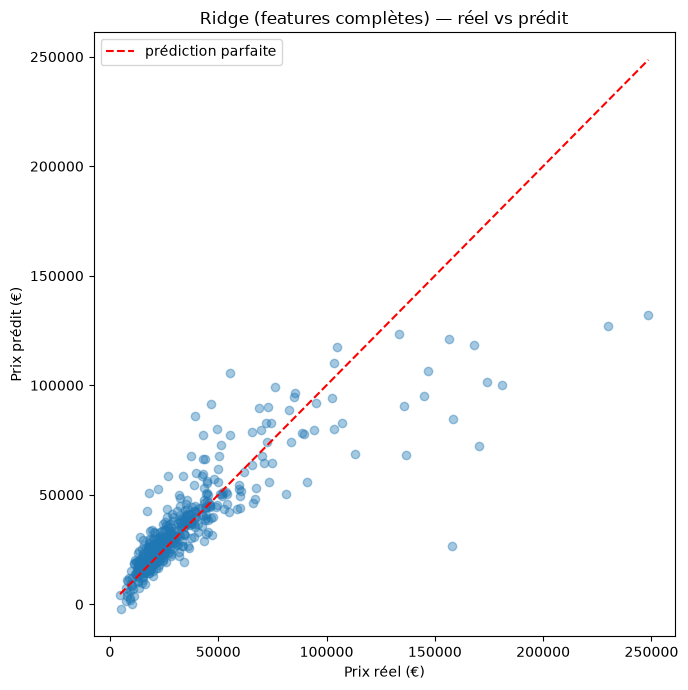

In [7]:
pred = est_ridge.predict(X_test[full])
plt.figure(figsize=(7,7))
plt.scatter(y_test, pred, alpha=0.4)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="prédiction parfaite")
plt.xlabel("Prix réel (€)"); plt.ylabel("Prix prédit (€)")
plt.title("Ridge (features complètes) — réel vs prédit"); plt.legend()
plt.tight_layout(); plt.show()

## Lecture

- Les **nouvelles features** (premium, boîte auto, garanties) font gagner par rapport à la baseline nue.
- **Ridge/Lasso/ElasticNet** régularisent : ils stabilisent les coefficients (ex. le `nombredeportes` négatif douteux de la baseline) au prix d'un léger biais — compromis **biais↑ / variance↓**.
- **Lasso/ElasticNet** = sélection de features (coefs à 0) → lecture de ce qui compte vraiment.
- Limite persistante : le linéaire modélise mal la **dépréciation non linéaire** → un modèle à arbres reste une piste, mais moins interprétable.
- Toujours pas de **fourchette + incertitude** (prochaine exigence produit).